### https://www.kaggle.com/datasets/somanshu7527/tiny-imagenet-10

In [2]:
import kornia.augmentation as K
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Check for NVIDIA GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


### 1. Model Creation

In [6]:
import torch.nn as nn

# Simple baseline CNN for Tinynet
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).view(x.size(0), -1))

### 2. Training Loop

In [ ]:
# for i,j in baseline_loader:
#     print(i.shape,j)

In [7]:
def train_epoch(model, loader, optimizer, criterion, device, use_mixup=False, alpha=0.4):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if use_mixup:
            images, soft_labels, _ = mixup_data(images, labels, alpha=alpha)
            optimizer.zero_grad()
            loss = soft_cross_entropy(model(images), soft_labels)
        else:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [8]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

In [9]:
# mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225].

TINY_IMAGENET_MEAN = (0.4802, 0.4481, 0.3975)
TINY_IMAGENET_STD = (0.2302, 0.2265, 0.2262)

# --- Baseline: no augmentation ---
baseline_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(TINY_IMAGENET_MEAN, TINY_IMAGENET_STD)
])

### 3. Define the data and load the data (simple model)

In [10]:
baseline_ds = ImageFolder(root='/kaggle/input/datasets/somanshu7527/tiny-imagenet-10/train', transform=transforms.ToTensor())
baseline_loader = DataLoader(baseline_ds, batch_size=128, shuffle=True, num_workers=2)

model_baseline = SimpleCNN().to(device)
opt_baseline   = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
criterion_base = nn.CrossEntropyLoss()

### 4. Define the data and load the data (With Data Augmentation)

In [11]:
aug_ds     = ImageFolder(root='/kaggle/input/datasets/somanshu7527/tiny-imagenet-10/train', transform=transforms.ToTensor())
aug_loader = DataLoader(aug_ds, batch_size=128, shuffle=True, num_workers=2)

model_aug = SimpleCNN().to(device)
opt_aug   = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

In [12]:
# Shared validation loader
val_ds   =  ImageFolder(root='/kaggle/input/datasets/somanshu7527/tiny-imagenet-10/val', transform=transforms.ToTensor())
val_load = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2)

history = {'baseline_loss': [], 'aug_loss': [],
           'baseline_val': [],  'aug_val': []}

In [13]:
from torch.functional import F

In [14]:
NUM_EPOCHS = 10

In [15]:
def mixup_data(x, y, alpha=0.4, num_classes=10):  # 200 classes for Tiny ImageNet
    """
    Apply Mixup to a batch.
    Returns mixed inputs and mixed soft labels (one-hot).
    """
    lam   = torch.distributions.Beta(alpha, alpha).sample().item()
    index = torch.randperm(x.size(0))
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a     = F.one_hot(y,        num_classes=num_classes).float()
    y_b     = F.one_hot(y[index], num_classes=num_classes).float()
    mixed_y = lam * y_a + (1 - lam) * y_b
    return mixed_x, mixed_y, lam

In [16]:
def soft_cross_entropy(logits, soft_targets):
    """
    Cross entropy loss that accepts soft (non-integer) label distributions.
    Equivalent to -sum(soft_targets * log_softmax(logits), dim=1).mean()
    """
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()

In [17]:
for epoch in range(1, NUM_EPOCHS + 1):
    bl = train_epoch(model_baseline, baseline_loader, opt_baseline, criterion_base,
                     device, use_mixup=False)
    al = train_epoch(model_aug,      aug_loader,      opt_aug,      criterion_base,
                     device, use_mixup=True, alpha=0.4)

    bv = evaluate(model_baseline, val_load, device)
    av = evaluate(model_aug,      val_load, device)

    history['baseline_loss'].append(bl)
    history['aug_loss'].append(al)
    history['baseline_val'].append(bv)
    history['aug_val'].append(av)

    print(f"Epoch {epoch}/{NUM_EPOCHS}  "
          f"Baseline: loss={bl:.3f} val_acc={bv:.3f}  |  "
          f"Augmented: loss={al:.3f} val_acc={av:.3f}")

Epoch 1/10  Baseline: loss=5.198 val_acc=0.292  |  Augmented: loss=4.372 val_acc=0.256
Epoch 2/10  Baseline: loss=1.692 val_acc=0.390  |  Augmented: loss=1.812 val_acc=0.438
Epoch 3/10  Baseline: loss=1.480 val_acc=0.434  |  Augmented: loss=1.619 val_acc=0.500
Epoch 4/10  Baseline: loss=1.347 val_acc=0.480  |  Augmented: loss=1.628 val_acc=0.476
Epoch 5/10  Baseline: loss=1.246 val_acc=0.480  |  Augmented: loss=1.555 val_acc=0.510
Epoch 6/10  Baseline: loss=1.178 val_acc=0.496  |  Augmented: loss=1.490 val_acc=0.516
Epoch 7/10  Baseline: loss=1.109 val_acc=0.480  |  Augmented: loss=1.366 val_acc=0.510
Epoch 8/10  Baseline: loss=1.085 val_acc=0.502  |  Augmented: loss=1.426 val_acc=0.506
Epoch 9/10  Baseline: loss=1.019 val_acc=0.514  |  Augmented: loss=1.294 val_acc=0.524
Epoch 10/10  Baseline: loss=0.976 val_acc=0.484  |  Augmented: loss=1.248 val_acc=0.500


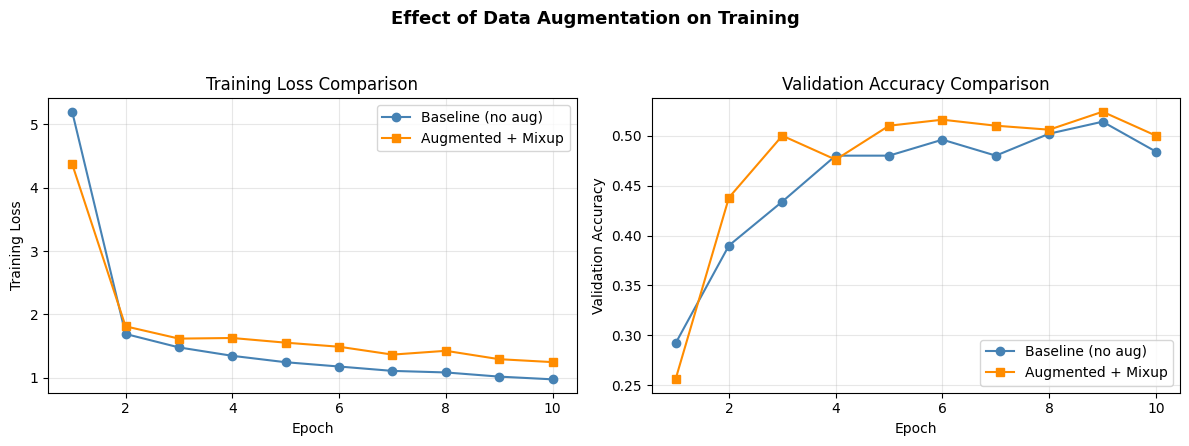

In [18]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(epochs, history['baseline_loss'], 'o-', label='Baseline (no aug)', color='steelblue')
ax1.plot(epochs, history['aug_loss'],      's-', label='Augmented + Mixup', color='darkorange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['baseline_val'], 'o-', label='Baseline (no aug)', color='steelblue')
ax2.plot(epochs, history['aug_val'],      's-', label='Augmented + Mixup', color='darkorange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Effect of Data Augmentation on Training', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [19]:
# Overfitting diagnostic: training vs validation accuracy gap

def compute_train_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


train_acc_baseline = compute_train_acc(model_baseline, baseline_loader, device)
train_acc_aug      = compute_train_acc(model_aug,      aug_loader,      device)
val_acc_baseline   = history['baseline_val'][-1]
val_acc_aug        = history['aug_val'][-1]

print("=" * 52)
print(f"{'Model':<20} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 52)
print(f"{'Baseline':<20} {train_acc_baseline:>10.3f} {val_acc_baseline:>10.3f} "
      f"{train_acc_baseline - val_acc_baseline:>8.3f}")
print(f"{'Augmented + Mixup':<20} {train_acc_aug:>10.3f} {val_acc_aug:>10.3f} "
      f"{train_acc_aug - val_acc_aug:>8.3f}")
print("=" * 52)
print("A smaller gap indicates less overfitting.")

Model                 Train Acc    Val Acc      Gap
----------------------------------------------------
Baseline                  0.600      0.484    0.116
Augmented + Mixup         0.662      0.500    0.162
A smaller gap indicates less overfitting.


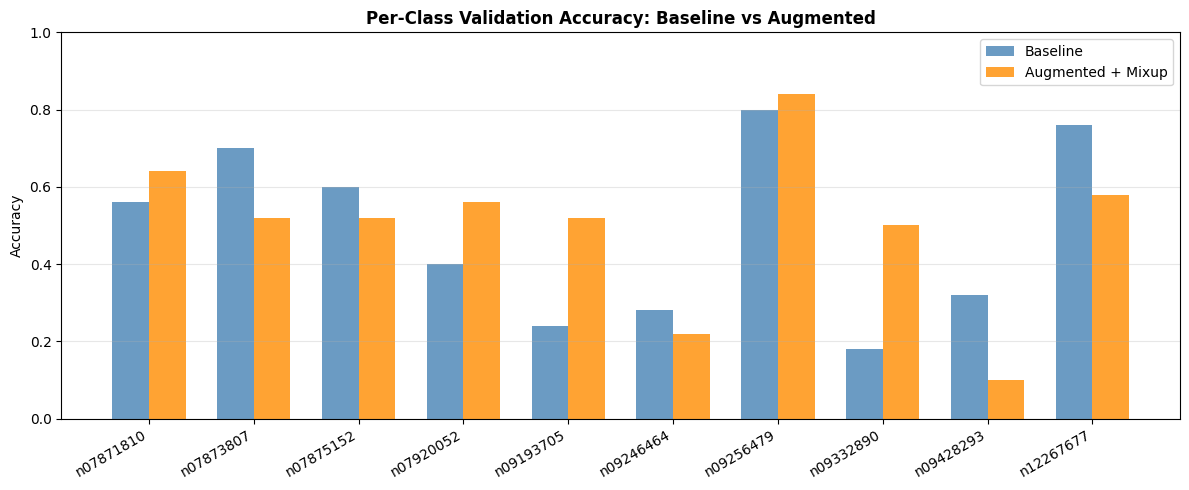

In [20]:
# Per-class accuracy to check if augmentation hurts any particular class
def per_class_accuracy(model, loader, classes, device):
    class_correct = {c: 0 for c in classes}
    class_total   = {c: 0 for c in classes}

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            for pred, label in zip(preds, labels):
                c = classes[label.item()]
                class_total[c]   += 1
                class_correct[c] += int(pred == label)

    return {c: class_correct[c] / max(class_total[c], 1) for c in classes}


classes_list = baseline_ds.classes
acc_base = per_class_accuracy(model_baseline, val_load, classes_list, device)
acc_aug  = per_class_accuracy(model_aug,      val_load, classes_list, device)

# Bar chart comparison
x = np.arange(len(classes_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [acc_base[c] for c in classes_list],
               width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [acc_aug[c] for c in classes_list],
               width, label='Augmented + Mixup', color='darkorange', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(classes_list, rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Validation Accuracy: Baseline vs Augmented', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()